# Fish Toxicity Model

In this notebook I will be building a linear 
regression model to predict the toxicity of 
chemicals to fish. I will be using the cleaned 
dataset from the cleaning phase. My target 
variable is LC50 and I will be using the 6 
chemical descriptors as my input features.

## Importing Libraries
Here I am importing everything I need to 
build and evaluate my model.

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler

## Loading the Cleaned Data
Here I am loading the cleaned dataset that I 
saved during the cleaning phase. This is the 
data I will use to build my model.

In [17]:
df = pd.read_csv('../data/clean_fish_toxicity.csv')
df.head()


,CIC0,SM1_Dz,GATS1i,NdsCH,NdssC,MLOGP,LC50
0,3.260,0.829,1.676,0,1,1.453,3.770
1,2.189,0.580,0.863,0,0,1.348,3.115
2,2.125,0.638,0.831,0,0,1.348,3.531
3,3.027,0.331,1.472,1,0,1.807,3.510
4,2.094,0.827,0.860,0,0,1.886,5.390


## Defining X and Y
Here I am separating my features (X) from my 
target variable (y). X contains all the chemical 
descriptors and y contains LC50 which is what 
I am trying to predict.

In [18]:
# X contains all columns except LC50
# these are my input features
X = df.drop('LC50', axis=1)

# y contains only LC50
# this is what I am trying to predict
y = df['LC50']

# confirming the shapes look right
print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')

X shape: (869, 6)
y shape: (869,)


## Splitting the Data
Here I am splitting the data into training and 
testing sets. I am using 80% of the data for 
training and 20% for testing. This way I can 
see how well my model performs on data it 
has never seen before.

In [19]:
# splitting data into 80% training and 20% testing
# random_state=42 makes sure I get the same 
# split every time I run this
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# confirming the shapes
print(f'X_train shape: {X_train.shape}')
print(f'X_test shape:  {X_test.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'y_test shape:  {y_test.shape}')

X_train shape: (695, 6)
X_test shape:  (174, 6)
y_train shape: (695,)
y_test shape:  (174,)


## Scaling the Data
Here I am scaling the data using StandardScaler.
I need to scale because all my features are on 
different scales and this can affect my model.
I am only fitting the scaler on training data 
so the test data stays unseen.

In [20]:
scaler = StandardScaler()
# fitting and transforming training data
# this learns the rules from training data
# and applies them at the same time
X_train_scaled = scaler.fit_transform(X_train)

# only transforming test data
# using the same rules from training data
# never fit on test data
X_test_scaled = scaler.transform(X_test)

## Building the Linear Regression Model
Here I am building my linear regression model.
I am training it on the scaled training data 
and then making predictions on the test data 
to see how well it performs.

In [21]:
# creating and training the model
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

# making predictions on test data
lr_pred = lr.predict(X_test_scaled)

# evaluating the model
lr_r2   = r2_score(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))

print(f'R2 Score: {lr_r2:.4f}')
print(f'RMSE:     {lr_rmse:.4f}')



R2 Score: 0.4501
RMSE:     1.0029


## Residual Plot
Here I am checking the residual plot to see 
if my model assumptions are met. I am looking 
for random scatter with no patterns.

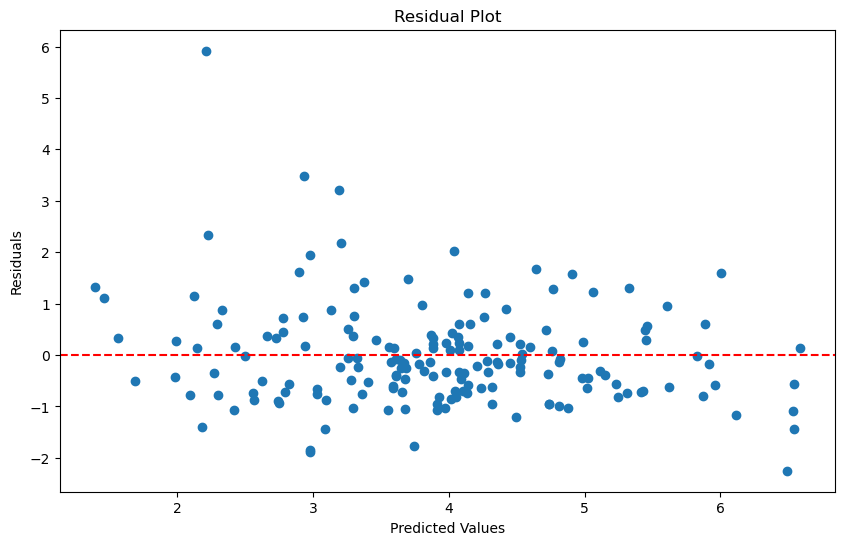

In [22]:
# calculating residuals
residuals = y_test - lr_pred

# plotting residuals
plt.figure(figsize=(10,6))
plt.scatter(lr_pred, residuals)
plt.axhline(0, linestyle='--', color='red')
plt.title('Residual Plot')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.show()

## Actual vs Predicted
Here I am plotting the actual LC50 values 
against my predicted values. A good model 
should have points close to the diagonal line.

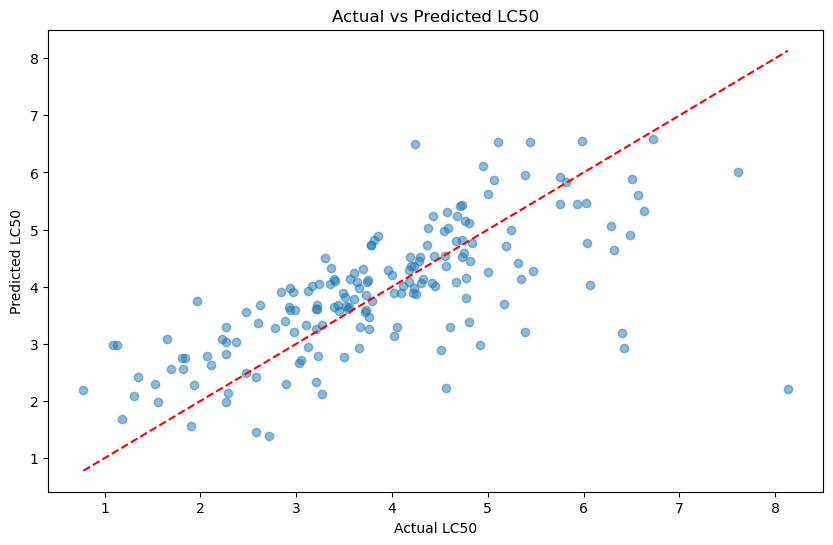

In [23]:
# plotting actual vs predicted values
plt.figure(figsize=(10,6))
plt.scatter(y_test, lr_pred, alpha=0.5)

# perfect predictions would follow this line
plt.plot([y_test.min(), y_test.max()], 
         [y_test.min(), y_test.max()], 
         'r--')

plt.title('Actual vs Predicted LC50')
plt.xlabel('Actual LC50')
plt.ylabel('Predicted LC50')
plt.show()

## Conclusions
After building my linear regression model 
I found:
- My R2 score was 0.4501 which means my model
  explains 45% of the variation in LC50
- My RMSE was 1.0029 which means on average
  my predictions are off by about 1 LC50 unit
- The model shows a moderate relationship
  between the chemical descriptors and LC50
- MLOGP was confirmed as the strongest 
  predictor of LC50 which matches what
  I found during EDA